# NB_04 — Análisis Estadístico Global

## Objetivo

Evaluar formalmente si las estrategias adaptativas presentan una mejora significativa y
consistente frente a ALL_HISTORY, integrando los resultados de los 3 datasets experimentales.

## Hipótesis

**H₁**: Las estrategias adaptativas (SLIDING_WINDOW, DECAY, DUAL_MODEL) presentan una mejora
significativa y consistente frente a ALL_HISTORY bajo escenarios de dinámica temporal y
delay de etiquetas.

## Framework estadístico

1. **Friedman test** — ¿Existen diferencias significativas entre las estrategias?
2. **Wilcoxon signed-rank** (pareado) — Cada adaptiva vs ALL_HISTORY
3. **Benjamini-Hochberg** — Corrección FDR para comparaciones múltiples
4. **Índice de dominancia pareada** — Tamaño del efecto + bootstrap CIs
5. **Mediana de deltas** — Relevancia práctica

## Inputs

| Dataset | Archivo |
|---------|--------|
| IEEE-CIS | `results/ieee_cis/experiment_results.csv` |
| BAF Variant IV | `results/baf_variant_iv/experiment_results.csv` |
| BAF Variant V | `results/baf_variant_v/experiment_results.csv` |

## Métrica principal: Average Precision / AUC-PR

In [14]:
# =============================================================================
# 1.1 Imports y configuración
# =============================================================================
import os
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)

print(f"Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Fecha de ejecución: 2026-06-02 15:44:38


In [15]:
# =============================================================================
# 1.2 Configuración y carga de datos
# =============================================================================

BASE_DIR    = r'./'
RESULTS_DIR = os.path.join(BASE_DIR, 'results', 'global_analysis')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Rutas de inputs
INPUT_FILES = {
    'IEEE_CIS': os.path.join(BASE_DIR, 'results', 'ieee_cis', 'experiment_results.csv'),
    'BAF_VARIANT_IV': os.path.join(BASE_DIR, 'results', 'baf_variant_iv', 'experiment_results.csv'),
    'BAF_VARIANT_V': os.path.join(BASE_DIR, 'results', 'baf_variant_v', 'experiment_results.csv'),
}

# Estrategias
STRATEGIES = ['STATIC', 'ALL_HISTORY', 'SLIDING_WINDOW', 'DECAY', 'DUAL_MODEL']
ADAPTIVE_STRATEGIES = ['SLIDING_WINDOW', 'DECAY', 'DUAL_MODEL']
BASELINE = 'ALL_HISTORY'

# Métrica principal
PRIMARY_METRIC = 'auc_pr'

# Nivel de significancia
ALPHA = 0.05

# Bootstrap config
N_BOOTSTRAP = 10000
CI_LEVEL = 0.95

# Cargar datos
dfs = []
for name, path in INPUT_FILES.items():
    if os.path.exists(path):
        tmp = pd.read_csv(path)
        print(f"✓ {name}: {tmp.shape[0]} filas")
        dfs.append(tmp)
    else:
        print(f"✗ {name}: NO ENCONTRADO en {path}")

df_all = pd.concat(dfs, ignore_index=True)
print(f"\nDataset combinado: {df_all.shape}")
print(f"Datasets: {df_all['dataset'].unique().tolist()}")
print(f"Estrategias: {df_all['strategy'].unique().tolist()}")
print(f"Delays: {sorted(df_all['delay'].unique().tolist())}")

✓ IEEE_CIS: 280 filas
✓ BAF_VARIANT_IV: 90 filas
✓ BAF_VARIANT_V: 90 filas

Dataset combinado: (460, 12)
Datasets: ['IEEE_CIS', 'BAF_VARIANT_IV', 'BAF_VARIANT_V']
Estrategias: ['STATIC', 'ALL_HISTORY', 'SLIDING_WINDOW', 'DECAY', 'DUAL_MODEL']
Delays: [0, 1, 2, 4]


---
## 2. Cálculo de deltas respecto a ALL_HISTORY

In [16]:
# =============================================================================
# 2.1 Calcular deltas: metric_strategy - metric_ALL_HISTORY
# =============================================================================

# Extraer baseline (ALL_HISTORY) por dataset, delay, eval_period
baseline = df_all[df_all['strategy'] == BASELINE][
    ['dataset', 'delay', 'eval_period', PRIMARY_METRIC]
].rename(columns={PRIMARY_METRIC: f'{PRIMARY_METRIC}_baseline'})

# Merge con todos los resultados
df_deltas = df_all.merge(baseline, on=['dataset', 'delay', 'eval_period'], how='left')
df_deltas['delta'] = df_deltas[PRIMARY_METRIC] - df_deltas[f'{PRIMARY_METRIC}_baseline']

# Filtrar solo estrategias adaptativas
df_adaptive = df_deltas[df_deltas['strategy'].isin(ADAPTIVE_STRATEGIES)].copy()

print(f"Deltas calculados: {len(df_adaptive)} observaciones")
print(f"  Estrategias adaptativas: {ADAPTIVE_STRATEGIES}")
print(f"  Baseline: {BASELINE}")

# Resumen rápido
print("\nResumen de deltas por estrategia:")
delta_overview = df_adaptive.groupby('strategy')['delta'].agg(
    ['mean', 'median', 'std', 'count']
).round(5)
print(delta_overview.to_string())

Deltas calculados: 276 observaciones
  Estrategias adaptativas: ['SLIDING_WINDOW', 'DECAY', 'DUAL_MODEL']
  Baseline: ALL_HISTORY

Resumen de deltas por estrategia:
                   mean   median      std  count
strategy                                        
DECAY           0.00315  0.00011  0.00565     92
DUAL_MODEL     -0.00018  0.00000  0.00585     92
SLIDING_WINDOW -0.00284  0.00000  0.00783     92


---
## 3. Test de Friedman (diferencias globales entre estrategias)

In [17]:
# =============================================================================
# 3.1 Friedman test
# =============================================================================

# Para Friedman necesitamos las métricas en formato wide:
# cada fila = una "muestra" (dataset × delay × eval_period)
# cada columna = una estrategia

# Usar solo las estrategias que queremos comparar (todas 5 o solo adaptivas + baseline)
friedman_strategies = STRATEGIES  # Incluir todas para test omnibus

pivot_friedman = df_all.pivot_table(
    index=['dataset', 'delay', 'eval_period'],
    columns='strategy',
    values=PRIMARY_METRIC
).dropna()

print(f"Friedman test — {len(pivot_friedman)} observaciones pareadas")
print(f"Estrategias: {pivot_friedman.columns.tolist()}")

# Ejecutar Friedman
friedman_data = [pivot_friedman[s].values for s in friedman_strategies if s in pivot_friedman.columns]
stat_friedman, p_friedman = friedmanchisquare(*friedman_data)

print(f"\n  Estadístico χ²: {stat_friedman:.4f}")
print(f"  p-value: {p_friedman:.2e}")
print(f"  Significativo (α={ALPHA}): {'SÍ' if p_friedman < ALPHA else 'NO'}")

# Rankings medios
from scipy.stats import rankdata
ranks = pivot_friedman[friedman_strategies].apply(
    lambda row: rankdata(-row), axis=1, result_type='expand'
)
ranks.columns = friedman_strategies
mean_ranks = ranks.mean().sort_values()

print("\n  Rankings medios (menor = mejor):")
for strategy, rank in mean_ranks.items():
    print(f"    {strategy:20s}: {rank:.3f}")

friedman_results = {
    'statistic': float(stat_friedman),
    'p_value': float(p_friedman),
    'n_observations': len(pivot_friedman),
    'mean_ranks': mean_ranks.to_dict(),
    'significant': bool(p_friedman < ALPHA)
}

with open(os.path.join(RESULTS_DIR, 'friedman_results.json'), 'w') as f:
    json.dump(friedman_results, f, indent=2)

print(f"\nGuardado: friedman_results.json")

Friedman test — 92 observaciones pareadas
Estrategias: ['ALL_HISTORY', 'DECAY', 'DUAL_MODEL', 'SLIDING_WINDOW', 'STATIC']

  Estadístico χ²: 150.6492
  p-value: 1.48e-31
  Significativo (α=0.05): SÍ

  Rankings medios (menor = mejor):
    DECAY               : 2.130
    ALL_HISTORY         : 2.685
    DUAL_MODEL          : 2.717
    SLIDING_WINDOW      : 3.011
    STATIC              : 4.457

Guardado: friedman_results.json


---
## 4. Wilcoxon signed-rank (cada adaptiva vs ALL_HISTORY) + Benjamini-Hochberg

In [18]:
# =============================================================================
# 4.1 Wilcoxon signed-rank tests + corrección BH
# =============================================================================

wilcoxon_results = []

for strategy in ADAPTIVE_STRATEGIES:
    # Deltas de esta estrategia vs ALL_HISTORY (por dataset × delay × eval_period)
    # dropna() evita que períodos sin ambas clases contaminen el test
    deltas = (
        df_adaptive[df_adaptive['strategy'] == strategy]['delta']
        .dropna()
        .values
    )
    
    # Pares efectivos para Wilcoxon: deltas distintos de cero
    n_total = len(deltas)
    n_nonzero = int(np.sum(deltas != 0))
    
    # Wilcoxon signed-rank
    # H0: mediana(delta) = 0
    # H1 two-sided: mediana(delta) != 0
    # Se usa two-sided por ser más conservador; la dirección se interpreta con mean/median delta.
    if n_total > 0 and n_nonzero > 0:
        stat_w, p_w = wilcoxon(deltas, alternative='two-sided')
    else:
        stat_w, p_w = np.nan, 1.0
    
    wilcoxon_results.append({
        'strategy': strategy,
        'n': n_total,
        'n_nonzero': n_nonzero,
        'median_delta': float(np.median(deltas)) if n_total > 0 else np.nan,
        'mean_delta': float(np.mean(deltas)) if n_total > 0 else np.nan,
        'statistic': float(stat_w) if not pd.isna(stat_w) else np.nan,
        'p_value': float(p_w)
    })

df_wilcoxon = pd.DataFrame(wilcoxon_results)

# Corrección Benjamini-Hochberg
reject, p_corrected, _, _ = multipletests(
    df_wilcoxon['p_value'].values,
    alpha=ALPHA,
    method='fdr_bh'
)

df_wilcoxon['p_corrected'] = p_corrected
df_wilcoxon['significant'] = reject

# Interpretación direccional
df_wilcoxon['direction'] = np.where(
    df_wilcoxon['mean_delta'] > 0,
    'favorable',
    np.where(df_wilcoxon['mean_delta'] < 0, 'unfavorable', 'neutral')
)

print("=" * 80)
print("WILCOXON SIGNED-RANK + BENJAMINI-HOCHBERG")
print("H0: Δ(strategy - ALL_HISTORY) = 0")
print("Nota: test two-sided; la dirección se interpreta con mean/median Δ.")
print("=" * 80)

for _, row in df_wilcoxon.iterrows():
    sig = (
        '***' if row['p_corrected'] < 0.001
        else ('**' if row['p_corrected'] < 0.01
        else ('*' if row['significant'] else 'ns'))
    )
    
    print(
        f"  {row['strategy']:20s} "
        f"n={int(row['n']):3d} "
        f"n_nonzero={int(row['n_nonzero']):3d} "
        f"mean Δ={row['mean_delta']:+.5f} "
        f"median Δ={row['median_delta']:+.5f} "
        f"p={row['p_value']:.4e} "
        f"p_BH={row['p_corrected']:.4e} "
        f"{sig} "
        f"({row['direction']})"
    )

df_wilcoxon.to_csv(os.path.join(RESULTS_DIR, 'wilcoxon_results.csv'), index=False)
print(f"\nGuardado: wilcoxon_results.csv")

WILCOXON SIGNED-RANK + BENJAMINI-HOCHBERG
H0: Δ(strategy - ALL_HISTORY) = 0
Nota: test two-sided; la dirección se interpreta con mean/median Δ.
  SLIDING_WINDOW       n= 92 n_nonzero= 63 mean Δ=-0.00284 median Δ=+0.00000 p=2.9663e-03 p_BH=4.4494e-03 ** (unfavorable)
  DECAY                n= 92 n_nonzero= 69 mean Δ=+0.00315 median Δ=+0.00011 p=2.8064e-06 p_BH=8.4191e-06 *** (favorable)
  DUAL_MODEL           n= 92 n_nonzero= 69 mean Δ=-0.00018 median Δ=+0.00000 p=5.8433e-01 p_BH=5.8433e-01 ns (unfavorable)

Guardado: wilcoxon_results.csv


---
## 5. Índice de dominancia pareada (tamaño del efecto) + Bootstrap CIs

In [19]:
# =============================================================================
# 5.1 Índice de dominancia pareada con bootstrap CIs
# =============================================================================

def paired_dominance_index(deltas):
    """
    Índice de dominancia pareada frente a cero.
    
    Se calcula como:
        proporción(delta > 0) - proporción(delta < 0)
    
    Rango: [-1, 1]
    > 0: la estrategia supera a ALL_HISTORY en más bloques de los que pierde.
    < 0: la estrategia pierde frente a ALL_HISTORY en más bloques de los que gana.
    
    Nota:
    Esta medida es análoga a una dominancia pareada, pero no se reporta como
    Cliff's Delta clásico entre dos muestras independientes.
    """
    deltas = pd.Series(deltas).dropna().values
    n = len(deltas)
    
    if n == 0:
        return np.nan
    
    n_pos = np.sum(deltas > 0)
    n_neg = np.sum(deltas < 0)
    
    return (n_pos - n_neg) / n


def bootstrap_ci(data, func, n_boot=N_BOOTSTRAP, ci=CI_LEVEL):
    """Bootstrap confidence interval."""
    data = pd.Series(data).dropna().values
    
    if len(data) == 0:
        return np.nan, np.nan
    
    boot_stats = []
    rng = np.random.default_rng(SEED)
    
    for _ in range(n_boot):
        sample = rng.choice(data, size=len(data), replace=True)
        boot_stats.append(func(sample))
    
    boot_stats = np.array(boot_stats)
    alpha_half = (1 - ci) / 2
    
    ci_lower = np.percentile(boot_stats, 100 * alpha_half)
    ci_upper = np.percentile(boot_stats, 100 * (1 - alpha_half))
    
    return ci_lower, ci_upper


def interpret_dominance(d):
    """
    Interpretación práctica del índice de dominancia.
    Umbrales orientativos, no equivalentes estrictos al Cliff's Delta clásico.
    """
    abs_d = abs(d)
    
    if abs_d < 0.147:
        return 'negligible'
    elif abs_d < 0.33:
        return 'small'
    elif abs_d < 0.474:
        return 'medium'
    else:
        return 'large'


# Calcular índice de dominancia pareada para cada estrategia adaptativa
effect_size_results = []

for strategy in ADAPTIVE_STRATEGIES:
    deltas = (
        df_adaptive[df_adaptive['strategy'] == strategy]['delta']
        .dropna()
        .values
    )
    
    dominance = paired_dominance_index(deltas)
    ci_lower, ci_upper = bootstrap_ci(deltas, paired_dominance_index)
    
    effect_size_results.append({
        'strategy': strategy,
        'paired_dominance_index': dominance,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'interpretation': interpret_dominance(dominance),
        'n': len(deltas),
        'wins': int(np.sum(deltas > 0)),
        'losses': int(np.sum(deltas < 0)),
        'ties': int(np.sum(deltas == 0)),
        'win_rate': float(np.mean(deltas > 0)) if len(deltas) > 0 else np.nan,
        'loss_rate': float(np.mean(deltas < 0)) if len(deltas) > 0 else np.nan
    })

df_effect = pd.DataFrame(effect_size_results)

print("=" * 90)
print("ÍNDICE DE DOMINANCIA PAREADA + Bootstrap 95% CI")
print("Definición: P(Δ > 0) - P(Δ < 0), donde Δ = strategy - ALL_HISTORY")
print("=" * 90)

for _, row in df_effect.iterrows():
    print(
        f"  {row['strategy']:20s} "
        f"D = {row['paired_dominance_index']:+.4f} "
        f"CI=[{row['ci_lower']:+.4f}, {row['ci_upper']:+.4f}] "
        f"({row['interpretation']}) "
        f"wins={int(row['wins'])}, losses={int(row['losses'])}, ties={int(row['ties'])}"
    )

df_effect.to_csv(os.path.join(RESULTS_DIR, 'effect_sizes.csv'), index=False)
print(f"\nGuardado: effect_sizes.csv")

ÍNDICE DE DOMINANCIA PAREADA + Bootstrap 95% CI
Definición: P(Δ > 0) - P(Δ < 0), donde Δ = strategy - ALL_HISTORY
  SLIDING_WINDOW       D = -0.1413 CI=[-0.3043, +0.0217] (negligible) wins=25, losses=38, ties=29
  DECAY                D = +0.3152 CI=[+0.1522, +0.4783] (small) wins=49, losses=20, ties=23
  DUAL_MODEL           D = -0.0761 CI=[-0.2500, +0.0978] (negligible) wins=31, losses=38, ties=23

Guardado: effect_sizes.csv


---
## 6. Análisis por dataset y delay

In [20]:
# =============================================================================
# 6.1 Wilcoxon por dataset × delay (granular)
# =============================================================================

granular_results = []

for dataset in df_adaptive['dataset'].unique():
    for delay in df_adaptive[df_adaptive['dataset'] == dataset]['delay'].unique():
        for strategy in ADAPTIVE_STRATEGIES:
            mask = (
                (df_adaptive['dataset'] == dataset) &
                (df_adaptive['delay'] == delay) &
                (df_adaptive['strategy'] == strategy)
            )
            
            deltas = df_adaptive.loc[mask, 'delta'].dropna().values
            
            if len(deltas) >= 5 and np.any(deltas != 0):
                stat_w, p_w = wilcoxon(deltas, alternative='two-sided')
                dominance = paired_dominance_index(deltas)
            else:
                stat_w, p_w = np.nan, np.nan
                dominance = np.nan
            
            granular_results.append({
                'dataset': dataset,
                'delay': delay,
                'strategy': strategy,
                'n': len(deltas),
                'median_delta': float(np.median(deltas)) if len(deltas) > 0 else np.nan,
                'mean_delta': float(np.mean(deltas)) if len(deltas) > 0 else np.nan,
                'wilcoxon_p': float(p_w) if not pd.isna(p_w) else np.nan,
                'paired_dominance_index': float(dominance) if not pd.isna(dominance) else np.nan
            })

df_granular = pd.DataFrame(granular_results)

# Corrección BH sobre todos los p-values granulares
valid_p = df_granular['wilcoxon_p'].dropna()

if len(valid_p) > 0:
    reject_gran, p_corr_gran, _, _ = multipletests(
        valid_p.values,
        alpha=ALPHA,
        method='fdr_bh'
    )
    df_granular.loc[valid_p.index, 'p_corrected'] = p_corr_gran
    df_granular.loc[valid_p.index, 'significant'] = reject_gran
else:
    df_granular['p_corrected'] = np.nan
    df_granular['significant'] = False

print("=" * 90)
print("ANÁLISIS GRANULAR: Wilcoxon + dominancia pareada por dataset × delay × strategy")
print("Nota: análisis descriptivo de heterogeneidad; la evidencia estadística principal es global.")
print("=" * 90)

for dataset in df_granular['dataset'].unique():
    print(f"\n{'─' * 40}")
    print(f"  Dataset: {dataset}")
    print(f"{'─' * 40}")
    
    sub = df_granular[df_granular['dataset'] == dataset]
    
    for _, row in sub.iterrows():
        sig = '*' if row.get('significant', False) else 'ns'
        d_str = (
            f"{row['paired_dominance_index']:+.3f}"
            if not pd.isna(row['paired_dominance_index'])
            else '  N/A'
        )
        print(
            f"    delay={row['delay']} {row['strategy']:18s} "
            f"mean Δ={row['mean_delta']:+.5f} "
            f"median Δ={row['median_delta']:+.5f} "
            f"D={d_str} {sig}"
        )

df_granular.to_csv(os.path.join(RESULTS_DIR, 'granular_analysis.csv'), index=False)
print(f"\nGuardado: granular_analysis.csv")

ANÁLISIS GRANULAR: Wilcoxon + dominancia pareada por dataset × delay × strategy
Nota: análisis descriptivo de heterogeneidad; la evidencia estadística principal es global.

────────────────────────────────────────
  Dataset: IEEE_CIS
────────────────────────────────────────
    delay=0 SLIDING_WINDOW     mean Δ=-0.00451 median Δ=-0.00266 D=-0.214 ns
    delay=0 DECAY              mean Δ=+0.00554 median Δ=+0.00446 D=+0.643 ns
    delay=0 DUAL_MODEL         mean Δ=-0.00127 median Δ=-0.00120 D=-0.357 ns
    delay=1 SLIDING_WINDOW     mean Δ=-0.00489 median Δ=+0.00000 D=+0.000 ns
    delay=1 DECAY              mean Δ=+0.00619 median Δ=+0.00635 D=+0.571 ns
    delay=1 DUAL_MODEL         mean Δ=+0.00124 median Δ=+0.00163 D=+0.286 ns
    delay=2 SLIDING_WINDOW     mean Δ=-0.00626 median Δ=-0.00294 D=-0.357 ns
    delay=2 DECAY              mean Δ=+0.00392 median Δ=+0.00107 D=+0.214 ns
    delay=2 DUAL_MODEL         mean Δ=-0.00005 median Δ=+0.00000 D=-0.071 ns
    delay=4 SLIDING_WINDOW     m

---
## 7. Visualizaciones finales

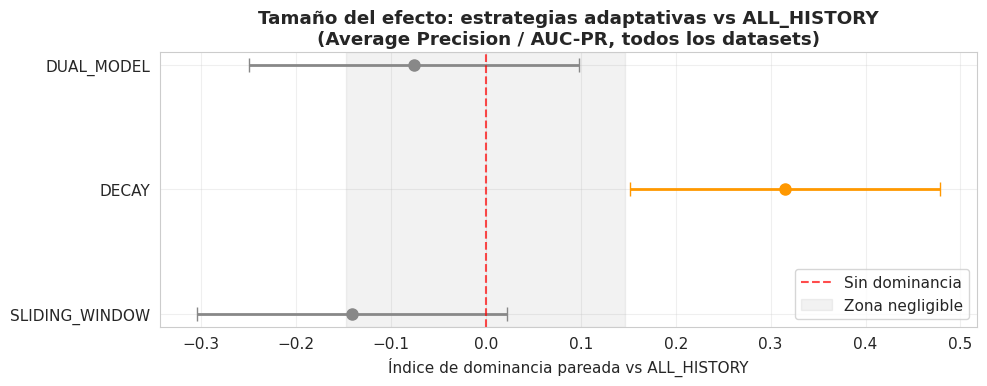

Guardado: forest_plot_paired_dominance.png


In [21]:
# =============================================================================
# 7.1 Forest plot: índice de dominancia pareada por estrategia
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 4))

y_positions = range(len(df_effect))
colors = {
    'negligible': '#888888',
    'small': '#FF9800',
    'medium': '#2196F3',
    'large': '#4CAF50'
}

for i, (_, row) in enumerate(df_effect.iterrows()):
    color = colors.get(row['interpretation'], '#888888')
    
    ax.errorbar(
        row['paired_dominance_index'],
        i,
        xerr=[
            [row['paired_dominance_index'] - row['ci_lower']],
            [row['ci_upper'] - row['paired_dominance_index']]
        ],
        fmt='o',
        color=color,
        capsize=5,
        markersize=8,
        linewidth=2
    )

ax.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Sin dominancia')
ax.axvspan(-0.147, 0.147, alpha=0.1, color='grey', label='Zona negligible')

ax.set_yticks(list(y_positions))
ax.set_yticklabels(df_effect['strategy'])
ax.set_xlabel("Índice de dominancia pareada vs ALL_HISTORY")
ax.set_title(
    "Tamaño del efecto: estrategias adaptativas vs ALL_HISTORY\n"
    "(Average Precision / AUC-PR, todos los datasets)",
    fontweight='bold'
)

ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(RESULTS_DIR, 'forest_plot_paired_dominance.png'),
    dpi=150,
    bbox_inches='tight'
)
plt.show()

print("Guardado: forest_plot_paired_dominance.png")

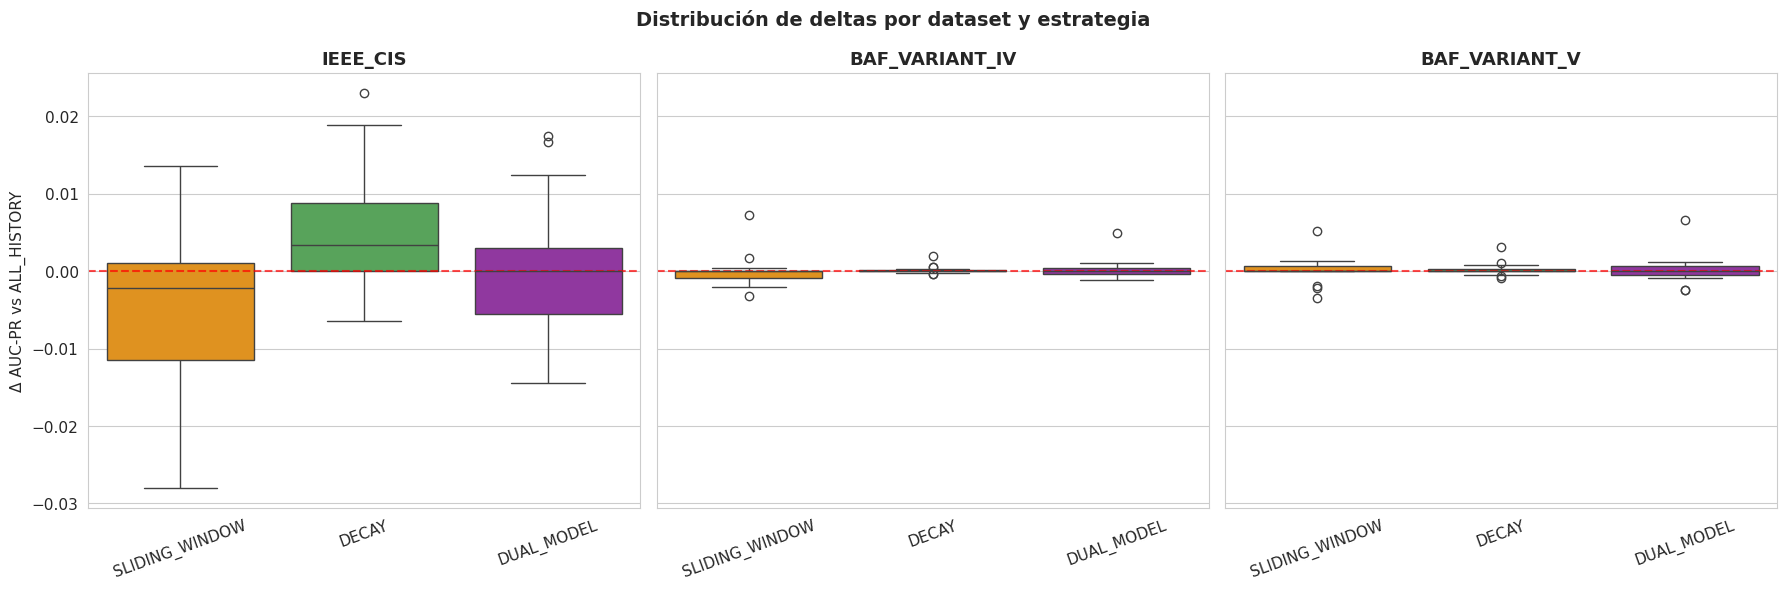

Guardado: boxplot_deltas_by_dataset.png


In [22]:
# =============================================================================
# 7.2 Boxplot de deltas por dataset × strategy
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

datasets = df_adaptive['dataset'].unique()

for idx, dataset in enumerate(datasets):
    ax = axes[idx]
    sub = df_adaptive[df_adaptive['dataset'] == dataset]
    
    sns.boxplot(
        data=sub, x='strategy', y='delta',
        order=ADAPTIVE_STRATEGIES, ax=ax,
        palette=['#FF9800', '#4CAF50', '#9C27B0']
    )
    
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.7)
    ax.set_title(dataset, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Δ AUC-PR vs ALL_HISTORY' if idx == 0 else '')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Distribución de deltas por dataset y estrategia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'boxplot_deltas_by_dataset.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: boxplot_deltas_by_dataset.png")

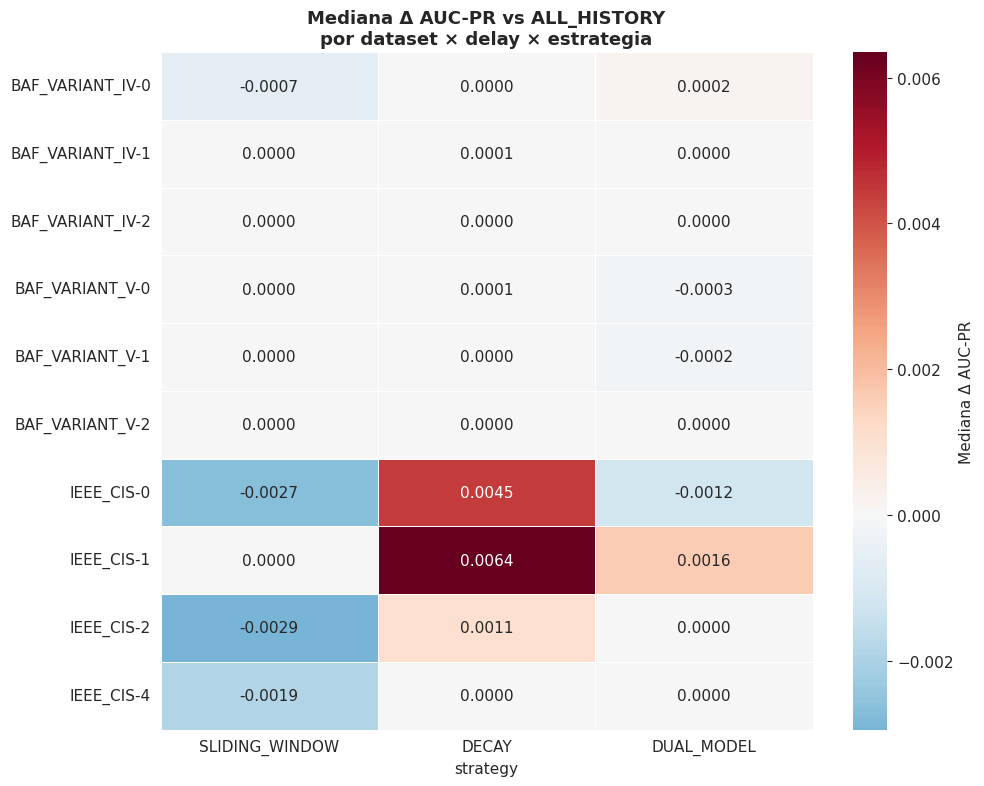

Guardado: heatmap_median_deltas.png


In [23]:
# =============================================================================
# 7.3 Heatmap: median delta por dataset × strategy × delay
# =============================================================================

# Pivotear para heatmap
heat_data = df_granular.pivot_table(
    index=['dataset', 'delay'],
    columns='strategy',
    values='median_delta'
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    heat_data[ADAPTIVE_STRATEGIES], annot=True, fmt='.4f',
    cmap='RdBu_r', center=0, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Mediana Δ AUC-PR'}
)
ax.set_title('Mediana Δ AUC-PR vs ALL_HISTORY\npor dataset × delay × estrategia',
             fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'heatmap_median_deltas.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: heatmap_median_deltas.png")

---
## 8. Conclusiones y resumen

In [29]:
# =============================================================================
# 8.1 Tabla resumen ejecutiva
# =============================================================================

print("=" * 90)
print("RESUMEN EJECUTIVO — ANÁLISIS ESTADÍSTICO GLOBAL")
print("=" * 90)

print(f"\n1. FRIEDMAN TEST (diferencias globales entre {len(friedman_strategies)} estrategias):")
print(f"   χ² = {stat_friedman:.4f}, p = {p_friedman:.2e}")
print(f"   Resultado: {'Diferencias significativas detectadas' if p_friedman < ALPHA else 'Sin diferencias significativas'}")

print(f"\n2. WILCOXON SIGNED-RANK (cada adaptiva vs ALL_HISTORY, corrección BH):")

for _, row in df_wilcoxon.iterrows():
    sig = '✓ Significativo' if row['significant'] else '✗ No significativo'
    
    if row['significant'] and row['mean_delta'] > 0:
        interpretation = 'mejora estadísticamente significativa'
    elif row['significant'] and row['mean_delta'] < 0:
        interpretation = 'diferencia significativa desfavorable'
    elif not row['significant'] and row['mean_delta'] > 0:
        interpretation = 'mejora no significativa'
    elif not row['significant'] and row['mean_delta'] < 0:
        interpretation = 'diferencia no significativa desfavorable'
    else:
        interpretation = 'sin diferencia relevante'
    
    print(
        f"   {row['strategy']:20s}: "
        f"p_BH = {row['p_corrected']:.4e}, "
        f"mean Δ = {row['mean_delta']:+.5f}, "
        f"median Δ = {row['median_delta']:+.5f} "
        f"[{sig}; {interpretation}]"
    )

print(f"\n3. ÍNDICE DE DOMINANCIA PAREADA:")
for _, row in df_effect.iterrows():
    print(
        f"   {row['strategy']:20s}: "
        f"D = {row['paired_dominance_index']:+.4f} "
        f"[{row['ci_lower']:+.4f}, {row['ci_upper']:+.4f}] "
        f"→ {row['interpretation']} "
        f"(wins={int(row['wins'])}, losses={int(row['losses'])}, ties={int(row['ties'])})"
    )

print(f"\n4. INTERPRETACIÓN GLOBAL:")

sig_favorable = df_wilcoxon[
    (df_wilcoxon['significant']) &
    (df_wilcoxon['mean_delta'] > 0)
]['strategy'].tolist()

sig_unfavorable = df_wilcoxon[
    (df_wilcoxon['significant']) &
    (df_wilcoxon['mean_delta'] < 0)
]['strategy'].tolist()

not_sig = df_wilcoxon[
    ~df_wilcoxon['significant']
]['strategy'].tolist()

if len(sig_favorable) == 0:
    print("   Ninguna estrategia adaptativa muestra una mejora estadísticamente significativa frente a ALL_HISTORY.")
else:
    print(f"   Estrategias con mejora estadísticamente significativa frente a ALL_HISTORY: {sig_favorable}")

if len(sig_unfavorable) > 0:
    print(f"   Estrategias con diferencia significativa desfavorable frente a ALL_HISTORY: {sig_unfavorable}")

if len(not_sig) > 0:
    print(f"   Estrategias sin diferencia estadísticamente significativa frente a ALL_HISTORY: {not_sig}")

print("\n   Conclusión para la hipótesis:")
if len(sig_favorable) == len(ADAPTIVE_STRATEGIES):
    print("   La hipótesis se sostiene ampliamente: todas las estrategias adaptativas mejoran significativamente frente a ALL_HISTORY.")
elif len(sig_favorable) > 0:
    print("   La hipótesis se sostiene solo parcialmente: algunas estrategias adaptativas mejoran, pero no de forma universal.")
else:
    print("   La hipótesis no se sostiene: no hay evidencia de mejora significativa de las estrategias adaptativas frente a ALL_HISTORY.")

RESUMEN EJECUTIVO — ANÁLISIS ESTADÍSTICO GLOBAL

1. FRIEDMAN TEST (diferencias globales entre 5 estrategias):
   χ² = 150.6492, p = 1.48e-31
   Resultado: Diferencias significativas detectadas

2. WILCOXON SIGNED-RANK (cada adaptiva vs ALL_HISTORY, corrección BH):
   SLIDING_WINDOW      : p_BH = 4.4494e-03, mean Δ = -0.00284, median Δ = +0.00000 [✓ Significativo; diferencia significativa desfavorable]
   DECAY               : p_BH = 8.4191e-06, mean Δ = +0.00315, median Δ = +0.00011 [✓ Significativo; mejora estadísticamente significativa]
   DUAL_MODEL          : p_BH = 5.8433e-01, mean Δ = -0.00018, median Δ = +0.00000 [✗ No significativo; diferencia no significativa desfavorable]

3. ÍNDICE DE DOMINANCIA PAREADA:
   SLIDING_WINDOW      : D = -0.1413 [-0.3043, +0.0217] → negligible (wins=25, losses=38, ties=29)
   DECAY               : D = +0.3152 [+0.1522, +0.4783] → small (wins=49, losses=20, ties=23)
   DUAL_MODEL          : D = -0.0761 [-0.2500, +0.0978] → negligible (wins=31, los

In [28]:
# =============================================================================
# 8.2 Guardar resumen final
# =============================================================================

sig_favorable = df_wilcoxon[
    (df_wilcoxon['significant']) &
    (df_wilcoxon['mean_delta'] > 0)
]['strategy'].tolist()

sig_unfavorable = df_wilcoxon[
    (df_wilcoxon['significant']) &
    (df_wilcoxon['mean_delta'] < 0)
]['strategy'].tolist()

not_significant = df_wilcoxon[
    ~df_wilcoxon['significant']
]['strategy'].tolist()

if len(sig_favorable) == len(ADAPTIVE_STRATEGIES):
    conclusion_text = (
        "La hipótesis se sostiene ampliamente: todas las estrategias adaptativas "
        "presentan mejoras estadísticamente significativas frente a ALL_HISTORY."
    )
elif len(sig_favorable) > 0:
    conclusion_text = (
        "La hipótesis se sostiene parcialmente: al menos una estrategia adaptativa "
        "presenta mejora estadísticamente significativa frente a ALL_HISTORY, "
        "pero la mejora no es universal entre estrategias."
    )
else:
    conclusion_text = (
        "La hipótesis no se sostiene: no se observa mejora estadísticamente significativa "
        "de las estrategias adaptativas frente a ALL_HISTORY."
    )

final_summary = {
    'experiment': {
        'hypothesis': 'Las estrategias adaptativas presentan una mejora significativa y consistente frente a ALL_HISTORY',
        'primary_metric': PRIMARY_METRIC,
        'primary_metric_interpretation': 'Average Precision / AUC-PR',
        'alpha': ALPHA,
        'n_datasets': len(INPUT_FILES),
        'n_strategies': len(STRATEGIES),
        'n_adaptive': len(ADAPTIVE_STRATEGIES),
        'total_observations': len(df_all)
    },
    'friedman': friedman_results,
    'wilcoxon_bh': df_wilcoxon.to_dict(orient='records'),
    'paired_dominance_index': df_effect.to_dict(orient='records'),
    'conclusion': {
        'significant_favorable': sig_favorable,
        'significant_unfavorable': sig_unfavorable,
        'not_significant': not_significant,
        'conclusion_text': conclusion_text
    }
}

with open(os.path.join(RESULTS_DIR, 'global_analysis_summary.json'), 'w') as f:
    json.dump(final_summary, f, indent=2, default=str)

print("=" * 70)
print("NB_04 — ANÁLISIS GLOBAL: COMPLETADO")
print("=" * 70)

print(f"\nConclusión automática:")
print(conclusion_text)

print(f"\nArchivos generados en {RESULTS_DIR}/:")

output_files = [
    'friedman_results.json',
    'wilcoxon_results.csv',
    'effect_sizes.csv',
    'granular_analysis.csv',
    'global_analysis_summary.json',
    'forest_plot_paired_dominance.png',
    'boxplot_deltas_by_dataset.png',
    'heatmap_median_deltas.png'
]

for f_name in output_files:
    fpath = os.path.join(RESULTS_DIR, f_name)
    exists = '✓' if os.path.exists(fpath) else '✗'
    print(f"  {exists} {f_name}")

NB_04 — ANÁLISIS GLOBAL: COMPLETADO

Conclusión automática:
La hipótesis se sostiene parcialmente: al menos una estrategia adaptativa presenta mejora estadísticamente significativa frente a ALL_HISTORY, pero la mejora no es universal entre estrategias.

Archivos generados en ./results/global_analysis/:
  ✓ friedman_results.json
  ✓ wilcoxon_results.csv
  ✓ effect_sizes.csv
  ✓ granular_analysis.csv
  ✓ global_analysis_summary.json
  ✓ forest_plot_paired_dominance.png
  ✓ boxplot_deltas_by_dataset.png
  ✓ heatmap_median_deltas.png
